# Practise Image Captioning

## 1. Import Libraries

In [1]:
import os  
import pandas as pd  
import spacy  # tokenize and lemmatize text
import torch
from torch.nn.utils.rnn import pad_sequence  
from torch.utils.data import DataLoader, Dataset
from PIL import Image  
from torchvision.models import Inception_V3_Weights
import torchvision.transforms as transforms

import torch
import torch.nn as nn
import torch.optim as optim
import statistics
import torchvision.models as models

from tqdm import tqdm
import torchvision.transforms as transforms

import matplotlib.pyplot as plt

## 2. Word Embedding

*We want to convert text into numeric values*
1. We need a dictionary that maps each word to an index
2. We need to set up a Pytorch dataset to load the data
3. Configure the filling of each batch (all sentences must be the same length)

In [2]:
spacy_eng = spacy.load("en_core_web_sm")

***Sentence Tokenization***

Tockenization = vectorization

In addition to embedding words into vectors, special tokens are used:

* `PAD` - used to align sentences. If a sentence is longer than the specified length, words are truncated. If it is shorter, `PAD` is added to the sentence until the required length is reached.
* `SOS` - "start of sentence" (same as \<start> in the image below) - the first token fed to the decoder along with the vector to begin generating response tokens.
* `EOS` - "end of sentence" - same as \<end> in the image below - once the decoder generates this token, we consider the response complete (regular punctuation marks cannot be used for this purpose, as their meanings may vary).
* `UNK` - "unknown token" - used to replace rare words that are not included in your dictionary. For example, the sentence "My name is guotong1999" would be translated to "My name is _`UNK`_"

<img src='https://cloud.githubusercontent.com/assets/2272790/18410099/1d0a1c1a-7761-11e6-9fe1-bd2e5622b90a.png'>

In [3]:
# Vocabulary creation
class Vocabulary:
    def __init__(self, freq_threshold):
        self.itos = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.freq_threshold = freq_threshold

    def __len__(self):
        return len(self.itos)

    @staticmethod
    def tokenizer_eng(text):
        return [tok.text.lower() for tok in spacy_eng.tokenizer(text)]

    def build_vocabulary(self, sentence_list):
        frequencies = {}
        idx = 4

        for sentence in sentence_list:
            for word in self.tokenizer_eng(sentence):
                if word not in frequencies:
                    frequencies[word] = 1
                else:
                    frequencies[word] += 1

                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

    def numericalize(self, text):
        tokenized_text = self.tokenizer_eng(text)

        return [
            self.stoi[token] if token in self.stoi else self.stoi["<UNK>"]
            for token in tokenized_text
        ]

## 3. Define and Load Flickr8k Dataset

In [4]:
class FlickrDataset(Dataset):
    def __init__(self, root_dir, captions_file, transform=None, freq_threshold=5):
        self.root_dir = root_dir
        self.df = pd.read_csv(captions_file)
        self.transform = transform

        # Store images and captions
        self.imgs = self.df["image"]
        self.captions = self.df["caption"]

        # Create vocabulary
        self.vocab = Vocabulary(freq_threshold)
        self.vocab.build_vocabulary(self.captions.tolist())

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        caption = self.captions[index]
        img_id = self.imgs[index]
        img = Image.open(os.path.join(self.root_dir, img_id)).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        numericalized_caption = [self.vocab.stoi["<SOS>"]]
        numericalized_caption += self.vocab.numericalize(caption)
        numericalized_caption.append(self.vocab.stoi["<EOS>"])

        return img, torch.tensor(numericalized_caption)


# Align image descriptions and their embeddings to a common format
class MyCollate:
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx

    def __call__(self, batch):
        imgs = [item[0].unsqueeze(0) for item in batch]
        imgs = torch.cat(imgs, dim=0)
        targets = [item[1] for item in batch]
        targets = pad_sequence(targets, batch_first=False, padding_value=self.pad_idx)

        return imgs, targets


def get_loader(
    root_folder,
    annotation_file,
    transform,
    batch_size=32,
    num_workers=0,
    shuffle=True,
    pin_memory=True,
):
    dataset = FlickrDataset(root_folder, annotation_file, transform=transform)

    pad_idx = dataset.vocab.stoi["<PAD>"]

    loader = DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        num_workers=num_workers,
        shuffle=shuffle,
        pin_memory=pin_memory,
        collate_fn=MyCollate(pad_idx=pad_idx),
    )

    return loader, dataset


transform = transforms.Compose(
        [transforms.Resize((356, 356)), transforms.ToTensor(),]
    )

loader, dataset = get_loader(
        "data/images/", "data/captions.txt", transform=transform
    )

for idx, (imgs, captions) in enumerate(loader):
    print(imgs.shape)
    print(captions.shape)

/Users/dmitriygolubitskiy/Library/Mobile Documents/com~apple~CloudDocs/Documents/Technology/Data Science/IDE2/DataCleaningProject/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


torch.Size([32, 3, 356, 356])
torch.Size([21, 32])
torch.Size([32, 3, 356, 356])
torch.Size([24, 32])
torch.Size([32, 3, 356, 356])
torch.Size([18, 32])
torch.Size([32, 3, 356, 356])
torch.Size([28, 32])
torch.Size([32, 3, 356, 356])
torch.Size([22, 32])
torch.Size([32, 3, 356, 356])
torch.Size([22, 32])
torch.Size([32, 3, 356, 356])
torch.Size([25, 32])
torch.Size([32, 3, 356, 356])
torch.Size([21, 32])
torch.Size([32, 3, 356, 356])
torch.Size([20, 32])
torch.Size([32, 3, 356, 356])
torch.Size([22, 32])
torch.Size([32, 3, 356, 356])
torch.Size([19, 32])
torch.Size([32, 3, 356, 356])
torch.Size([20, 32])
torch.Size([32, 3, 356, 356])
torch.Size([26, 32])
torch.Size([32, 3, 356, 356])
torch.Size([27, 32])
torch.Size([32, 3, 356, 356])
torch.Size([22, 32])
torch.Size([32, 3, 356, 356])
torch.Size([24, 32])
torch.Size([32, 3, 356, 356])
torch.Size([19, 32])
torch.Size([32, 3, 356, 356])
torch.Size([22, 32])
torch.Size([32, 3, 356, 356])
torch.Size([23, 32])
torch.Size([32, 3, 356, 356])
t

## 4. Model Definition

The image captioning model consists of an encoder and a decoder. The encoder is a linear layer, which is used immediately after the pretrained ***CNN***. The decoder is an ***RNN***.

<img src='https://raw.githubusercontent.com/yunjey/pytorch-tutorial/master/tutorials/03-advanced/image_captioning/png/model.png'>

In [5]:
class EncoderCNN(nn.Module):
    def __init__(self, embed_size, train_CNN=False):
        super(EncoderCNN, self).__init__()
        self.train_CNN = train_CNN
        # Loading pretrained CNN model
        self.inception = models.inception_v3(weights=Inception_V3_Weights.DEFAULT, aux_logits=True)
        # Replacing the last layer - classifier with an embedder
        self.inception.fc = nn.Linear(self.inception.fc.in_features, embed_size)
        self.relu = nn.ReLU()
        self.times = []
        self.dropout = nn.Dropout(0.5)

    def forward(self, images):
        features = self.inception(images)
        if hasattr(features, 'logits'):
            features = features.logits
        return self.dropout(self.relu(features))


class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super(DecoderRNN, self).__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers)
        self.linear = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(0.5)

    def forward(self, features, captions):
        embeddings = self.dropout(self.embed(captions))
        embeddings = torch.cat((features.unsqueeze(0), embeddings), dim=0)
        hiddens, _ = self.lstm(embeddings)
        outputs = self.linear(hiddens)
        return outputs


class CNNtoRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super(CNNtoRNN, self).__init__()
        self.encoderCNN = EncoderCNN(embed_size)
        self.decoderRNN = DecoderRNN(embed_size, hidden_size, vocab_size, num_layers)

    def forward(self, images, captions):
        features = self.encoderCNN(images)
        outputs = self.decoderRNN(features, captions)
        return outputs

    def caption_image(self, image, vocabulary, max_length=50):
        result_caption = []

        with torch.no_grad():
            x = self.encoderCNN(image).unsqueeze(0)
            states = None

            for _ in range(max_length):
                hiddens, states = self.decoderRNN.lstm(x, states)
                output = self.decoderRNN.linear(hiddens.squeeze(0))
                predicted = output.argmax(1)
                result_caption.append(predicted.item())
                x = self.decoderRNN.embed(predicted).unsqueeze(0)

                if vocabulary.itos[predicted.item()] == "<EOS>":
                    break

        return [vocabulary.itos[idx] for idx in result_caption]

## 5. Training the Model

In [6]:
def train():
    train_losses = []
    
    transform = transforms.Compose(
        [
            transforms.Resize((356, 356)),
            transforms.RandomCrop((299, 299)),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ]
    )

    train_loader, dataset = get_loader(
        root_folder="data/images",
        annotation_file="data/captions.txt",
        transform=transform,
        num_workers=0,
    )

    torch.backends.cudnn.benchmark = True
    device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
    train_CNN = False

    # Hyperparameters
    embed_size = 1024
    hidden_size = 1024
    vocab_size = len(dataset.vocab)
    num_layers = 1
    learning_rate = 3e-4
    num_epochs = 10


    # Initialize
    model = CNNtoRNN(embed_size, hidden_size, vocab_size, num_layers).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=dataset.vocab.stoi["<PAD>"])
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Only fine-tuning of CNN
    for name, param in model.encoderCNN.inception.named_parameters():
        if "fc.weight" in name or "fc.bias" in name:
            param.requires_grad = True
        else:
            param.requires_grad = train_CNN

    model.train()

    for epoch in range(num_epochs):
        print(f"Epoch [{epoch+1}/{num_epochs}]")

        for idx, (imgs, captions) in tqdm(
            enumerate(train_loader), total=len(train_loader), leave=False
        ):
            imgs = imgs.to(device)
            captions = captions.to(device)

            outputs = model(imgs, captions[:-1])
            loss = criterion(
                outputs.reshape(-1, outputs.shape[2]), captions.reshape(-1)
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

    return model, dataset, train_losses, device

Training the model and visualizing the losses.

Epoch [1/10]


Epoch [2/10]


Epoch [3/10]


Epoch [4/10]


Epoch [5/10]


Epoch [6/10]


Epoch [7/10]


Epoch [8/10]


Epoch [9/10]


Epoch [10/10]


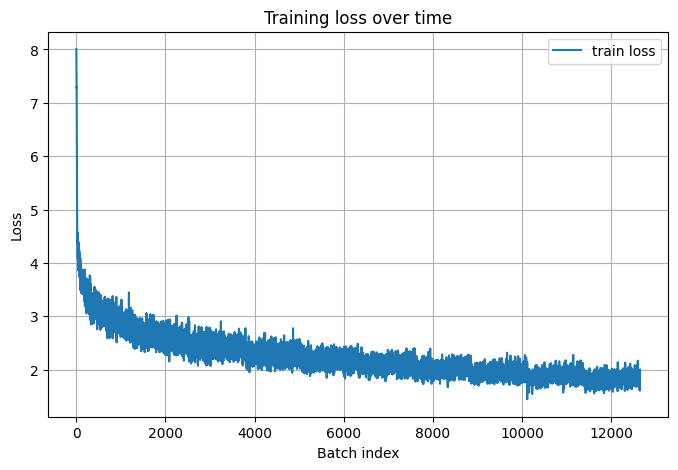

In [7]:
model, dataset, train_losses, device = train()

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="train loss")
plt.xlabel("Batch index")
plt.ylabel("Loss")
plt.title("Training loss over time")
plt.legend()
plt.grid(True)
plt.show()

## 6. Empirical Model Validation and Results Visualization

The best results have been received with the embedding size 1024 and 10 epochs of training. The code and the output blow belongs to that training set-up.

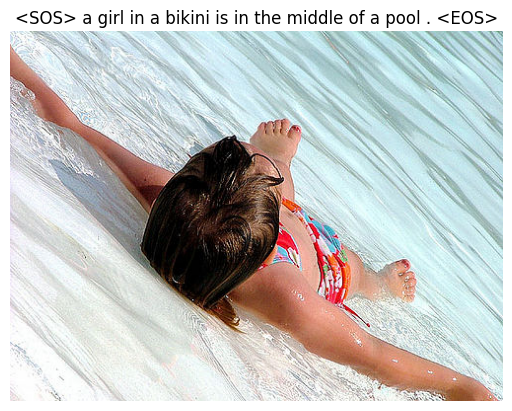

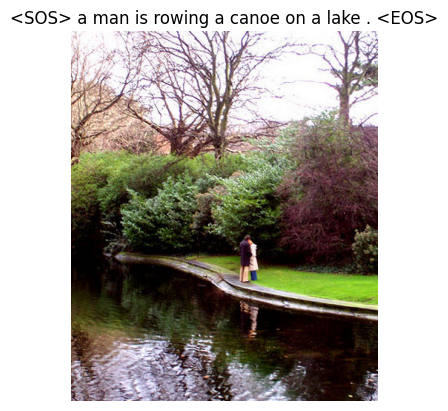

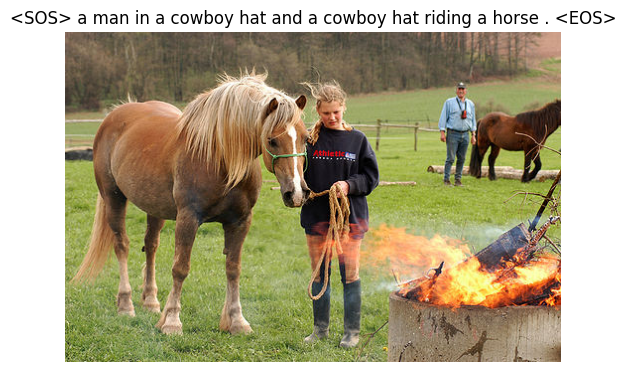

In [8]:
from PIL import Image
import matplotlib.pyplot as plt

def show_caption(image_path, model, vocab, transform):
    model.eval()
    image = Image.open(image_path).convert("RGB")

    inference_transform = transforms.Compose([
        transforms.Resize((356, 356)),
        transforms.CenterCrop((299, 299)),  # Use CenterCrop instead of RandomCrop
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])
    
    tensor = inference_transform(image).unsqueeze(0).to(device)
    

    with torch.no_grad():
        caption_tokens = model.caption_image(tensor, vocab)
    caption = " ".join(caption_tokens)

    plt.imshow(image)
    plt.axis("off")
    plt.title(caption)
    plt.show()


show_caption("data/images/667626_18933d713e.jpg", model, dataset.vocab, transform)
show_caption("data/images/3637013_c675de7705.jpg", model, dataset.vocab, transform)
show_caption("data/images/10815824_2997e03d76.jpg", model, dataset.vocab, transform)


The following out put is for the embedding size 512 and number of epochs 10. The quality of captions is lower.